# Pseudomode mapping for spin-boson model with underdamped Brownian bath

## Introduction

This notebook applies the approach of (Pleasance et al) to simulate the dynamics of the spin-boson model with underdamped spectral density. 

Further details on the spin-boson model are included in [pm_ohmic.ipynb](./notebooks/pm_ohmic.ipynb). 

The underdamped Brownian spectral density reads
\begin{equation*}
    J(\omega) = \frac{2\lambda^2\omega_0\Gamma\omega}{(\omega^2-\omega^2_0)^2 + \Gamma^2\omega^2},
\end{equation*}
where $\lambda$ measures the total system-bath coupling strength, $\Gamma$ is the bath width, and $\omega_0$ the resonance frequency. 

The bath correlation function (BCF) corresponding to this spectral density is given as
\begin{align*}
    C^B(t) &:= C_0(t) + M(t) \\
         &= \frac{\lambda^2\omega_0}{2\Omega}\bigg[\bigg(\coth\frac{\beta(\Omega-i\Gamma/2)}{2} + 1\bigg)e^{-i\Omega t} + \bigg(\coth\frac{\beta(\Omega+i\Gamma/2)}{2} - 1\bigg)e^{i\Omega t}\bigg]e^{-\Gamma|t|/2} + M(t),
\end{align*}
where $\beta = \frac{1}{k_BT}$ is the inverse bath temperature, $\Omega = \sqrt{\omega^2_0 - \frac{\Gamma^2}{4}}$, and 
\begin{equation*}
    M(t) = -i\frac{2}{\beta}\sum^{\infty}_{k=1}J(-i\nu_k)e^{-\nu_k |t|}
\end{equation*}
with Matsubara frequencies $\nu_k = \frac{2\pi k}{\beta}$ ($k\in\mathbb{N}$). 

Another useful quantity to consider is the bath noise spectrum 
\begin{equation*}
    \gamma(\omega) = 2\,{\rm Re}\int^{\infty}_0dt\,C^B(t)e^{i\omega t},
\end{equation*}
defined as the Fourier transform of $C^B(t)$, where $\gamma(\omega)\geq 0$ holds by definition.

In [56]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib as mpl 
from numpy import linalg
from scipy.linalg import expm

# Import fitting library
from lmfit import minimize, Parameters

In [87]:
# Parameters (units of system energy eps)
eps = 1.0
T = 0.25
Gm = 0.1
om0 = 1
N_exp = 2
lmb = 0.5
Om = np.sqrt(om0 **2 - Gm **2 / 4)

tlist = np.linspace(0, 50, 500)
omlist = np.linspace(-2, 2, 500) 

# Bath correlation function
bcf = qt.UnderDampedEnvironment(T=T, lam=np.sqrt(2)*lmb, gamma=Gm, w0=om0).correlation_function(tlist)  # NB: scale lmb for consistency

# Bath spectrum
spec = qt.UnderDampedEnvironment(T=T, lam=np.sqrt(2)*lmb, gamma=Gm, w0=om0).power_spectrum(omlist)

c0 = np.real(bcf[0])

## Fitting of bath correlation function

To extract the pseudomode parameters, we first need to fit $C^B(t)$ with a sum of $N$ complex exponentials
\begin{equation*}
    C^E(t) = -i\sum^N_{l=1}r_le^{-iz_lt}, \qquad t\geq0,
\end{equation*}
where $z_l$ and $r_l$ are both complex. 

It is also possible perform the same fitting in Fourier space using the target function
\begin{align*}
    \gamma'(\omega) &= 2\,{\rm Re}\int^{\infty}_0dt\,C^E(t)e^{i\omega t} \\
                    &= \sum^N_{l=1}\frac{ir_l}{\omega - z_l} - \frac{ir^*_l}{\omega - z^*_l},
\end{align*}
assuming $C^E(-t) = C^E(t)^*$. 

In [ ]:
# Fit BCF with complex exponentials 
def residuals(params, t, corr):
    #
    r1r = params['residue_real_1'].value
    r1i = params['residue_imag_1'].value
    r2r = params['residue_real_2'].value
    r2i = params['residue_imag_2'].value
    z1r = params['z_real_1'].value
    z1i = params['z_imag_1'].value
    z2r = params['z_real_2'].value
    z2i = params['z_imag_2'].value

    bcf_fit =  -1.0j*(r1r + 1.0j*r1i)*np.exp(-1.0j*(z1r-1.0j*z1i)*tlist) \
             +  -1.0j*(r2r + 1.0j*r2i)*np.exp(-1.0j*(z2r-1.0j*z2i)*tlist)
            
    residual_corr = corr - bcf_fit
    
    return residual_corr.view(float)

params = Parameters() 
params.add('c0', value=c0, vary=False)
params.add('residue_real_1', value=1)
params.add('residue_imag_1', value=1)
params.add('residue_real_2',  expr='-residue_real_1')
params.add('residue_imag_2',  expr='c0-residue_imag_1')
params.add('z_real_1', value=Om)
params.add('z_real_2', value=-Om)  # fix to -xi_1 to obtain +ve PM decay rates?
params.add('z_imag_1', value=Gm, min=0)
params.add('z_imag_2', value=Gm, min=0)  # 'expr=z_imag_1'

result = minimize(residuals, params, method='leastsq', args=(tlist, bcf))

# Get fit parameters 
r1r = result.params['residue_real_1'].value
r1i = result.params['residue_imag_1'].value
r2r = result.params['residue_real_2'].value
r2i = result.params['residue_imag_2'].value
z1r = result.params['z_real_1'].value
z1i = result.params['z_imag_1'].value
z2r = result.params['z_real_2'].value
z2i = result.params['z_imag_2'].value


/Users/GraemePleasance/anaconda3/envs/qutip-env/lib/python3.12/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


In [125]:
# Extract coefficients and exponents of C^i = \sum_k c^i_k * exp(-v^i_k * t), where i = {real, imag} and C = C^R + 1j*C^I.
# Coefficients
ck = np.array([-1j*(r1r + 1.0j*r1i), -1j*(r2r + 1.0j*r2i)])
ck_real = list(0.5 * ck) + list(0.5 * np.conj(ck))
ck_imag = list(0.5j * np.conj(ck)) + list(-0.5j * ck)

# Exponents
vk = np.array([1j*(z1r-1j*z1i), 1j*(z2r-1j*z2i)])
vk_real = list(vk) + list(np.conj(vk))
vk_imag = list(np.conj(vk)) + list(vk)

bath_fit = qt.ExponentialBosonicEnvironment(ck_real=ck_real, ck_imag=ck_imag, vk_real=vk_real, vk_imag=vk_imag, combine=True) 

The error in the fit of the BCF and/or bath spectrum may be quantified through the measures
\begin{equation*}
    \Delta C(t) = |C^B(t) - C^E(t)|,
\end{equation*}
and 
\begin{equation*}
    \Delta\gamma(\omega) = |\gamma(\omega) - \gamma'(\omega)|.
\end{equation*}

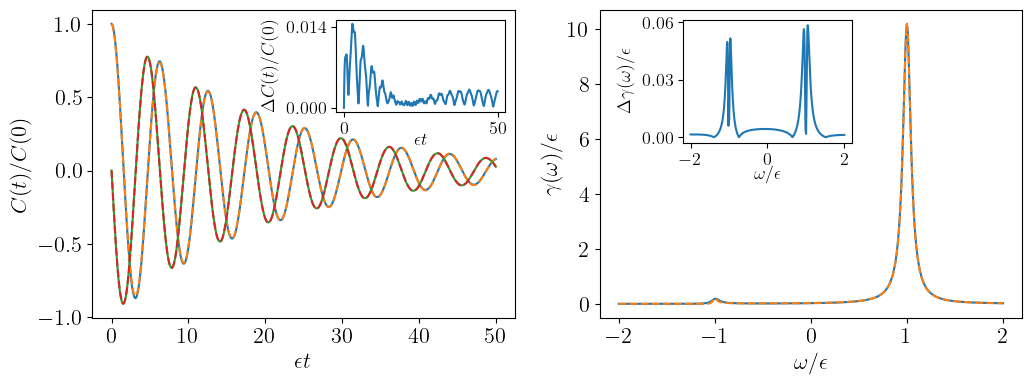

In [154]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Plots of physical and fitted BCFs
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['text.usetex'] = True

fig1, ax1 = plt.subplots(1,2, figsize=(12,4))

# BCF
ax1[0].plot(tlist, np.real(bcf) / c0, label=r'$\mathrm{Exact \, (real)}$')
ax1[0].plot(tlist, np.real(bath_fit.correlation_function(tlist)) / c0, linestyle='--', label=r'$\mathrm{Fit \, (real)}')
ax1[0].plot(tlist, np.imag(bcf) / c0, label=r'$\mathrm{Exact \, (imag)}$')
ax1[0].plot(tlist, np.imag(bath_fit.correlation_function(tlist)) / c0, linestyle='--', label=r'$\mathrm{Fit \, (imag)}')

ax1[0].set_xlabel(r'$\epsilon t$')
ax1[0].set_ylabel(r'$C(t)/C(0)$')

# Error - BCF
bcf_err = np.abs(bcf - bath_fit.correlation_function(tlist))

ax1_inset_left = inset_axes(ax1[0], width='40%', height='30%', loc='upper right')
ax1_inset_left.plot(tlist, bcf_err / c0)

ax1_inset_left.tick_params(labelsize=13)
ax1_inset_left.set_xticks([min(tlist), max(tlist)])
ax1_inset_left.set_yticks([0, np.round(np.max(bcf_err) / c0, 3)])
ax1_inset_left.set_ylabel(r'$\Delta C(t) / C(0)$', fontsize=13, labelpad=5)
ax1_inset_left.set_xlabel(r'$\epsilon t$', fontsize=13, labelpad=-4)

# Spectrum
ax1[1].plot(omlist, spec, label=r'$\mathrm{Exact}$')
ax1[1].plot(omlist, bath_fit.power_spectrum(omlist), linestyle='--', label=r'$mathrm{Fit}$')

ax1[1].set_xlabel(r'$\omega/\epsilon$')
ax1[1].set_ylabel(r'$\gamma(\omega) / \epsilon$')

# Error - spectrum
spec_err = np.abs(spec - bath_fit.power_spectrum(omlist))

ax1_inset_right = inset_axes(ax1[1], width='40%', height='40%',
                             bbox_to_anchor=(-0.38, 0, 1, 1),  # (x, y, width, height)
                             bbox_transform=ax1[1].transAxes)

ax1_inset_right.plot(omlist, spec_err)

ax1_inset_right.tick_params(labelsize=13)
ax1_inset_right.set_yticks([0, 0.5 * np.round(np.max(spec_err), 2), np.round(np.max(spec_err),2)])
ax1_inset_right.set_ylabel(r"$\Delta\gamma(\omega)/\epsilon$", fontsize=13, labelpad=5)
ax1_inset_right.set_xlabel(r'$\omega/\epsilon$', fontsize=13, labelpad=-2)

plt.show()

In [144]:
np.max(bcf_err)

np.float64(0.003681049079550159)

## Pseudomode parameters

Re-express fitted correlation function in the form 
\begin{equation}
C^E(t) = \boldsymbol{g}^Te^{-i\boldsymbol{\Lambda} t}\boldsymbol{g}, \qquad t\geq0,
\end{equation}
where $\boldsymbol{\Lambda} = {\rm diag}(z_1,...,z_N)$ and $\boldsymbol{g} = (\sqrt{-ir_1},...,\sqrt{-ir_N})^T$.

In [156]:
from pseudomodes.pure_dephasing import pm_parameters

# Extract pole locations zk and residues rk from fitting data ck, vk.
rk = 1j * ck
zk = np.diag(-1j * vk)

g, xi, gm, info = pm_parameters(rk=rk, zk=zk, info=True)

print(info['all'])

g = 
 [0.36669 0.34631]

xi = 
 [[ 0.2539   0.97038]
 [ 0.97038 -0.26305]]

gm = 
 [ 0.16318 -0.01022]


## PMME simulation: independent boson model (IBM)

To benchmark the PMME results, we consider an exactly solvable version of the spin-boson model - the independent boson model - where the system undergoes a purely dephasing dynamics ($\Delta =0$):
\begin{equation*}
 H = \frac{\epsilon}{2}\sigma_z + \sum_k\omega_ka^{\dagger}_ka_k + \sigma_z\otimes B.
\end{equation*}
The system Bloch vector in this case evolves according to
\begin{equation*}
    \begin{pmatrix}
    \langle \sigma_x(t)\rangle \\ 
    \langle \sigma_y(t)\rangle \\ 
    \langle \sigma_z(t)\rangle
    \end{pmatrix}
    =
    \begin{pmatrix}
    2\,{\rm Re}[e^{i\epsilon t + \phi(t)}\rho_{10}] \\ 
    2\,{\rm Im}[e^{i\epsilon t + \phi(t)}\rho_{10}]  \\ 
    \langle \sigma_z(0)\rangle
    \end{pmatrix},
\end{equation*}
where $\rho_{10} = \langle 1|\rho_S(t)|0\rangle$, and 
\begin{equation*}
    \phi(t) = -\frac{4}{\pi}\int^{\infty}_0d\omega\frac{J(\omega)}{\omega^2}\coth\left(\frac{\beta\omega}{2}\right)(1-\cos\omega t).
\end{equation*}

In [133]:
# Construct PMME
tlist_pm = np.linspace(0, 25, 500)

# Local PM dims
N1, N2 = 9, 9
Nlist = [N1, N2]

# Initial system + PM state
init_state = qt.tensor([qt.ket2dm((qt.basis(2) + qt.basis(2,1)).unit())] + [qt.fock_dm(N) for N in Nlist])

sigx = qt.tensor([qt.sigmax()] + [qt.identity(N) for N in Nlist])
sigy = qt.tensor([qt.sigmay()] + [qt.identity(N) for N in Nlist])
sigz = qt.tensor([qt.sigmaz()] + [qt.identity(N) for N in Nlist])

b_ops = []
for n in range(len(Nlist)): 
  b_ops.append(qt.tensor([qt.identity(2)] + [qt.destroy(N) if n == idx else qt.identity(N) for idx, N in enumerate(Nlist)]))

# Hamiltonian
H_S = 1/2 * eps * sigz
H_E = 0 
H_I = 0
for i in range(len(b_ops)):
    H_I += g[i] * sigz * (b_ops[i] + b_ops[i].dag())
    for j in range(len(b_ops)):
        H_E += xi[i][j] * b_ops[i].dag() * b_ops[j] 

H = H_S + H_E + H_I

# Construct GKSL part of dissipator
L_sys_pm = qt.liouvillian(H=H, c_ops=[np.sqrt(dr) * b_ops[i] if dr > 0 else 0 * b_ops[i] for i, dr in enumerate(np.diag(gm))])

# Add non-GKSL part (negative decay rates)
for i, dr in enumerate(np.diag(gm)):
    if dr < 0:
        L_sys_pm -= qt.lindblad_dissipator(a=np.sqrt(np.abs(dr)) * b_ops[i])

In [134]:
# Solve PMME
result = qt.mesolve(L_sys_pm, init_state, tlist_pm, e_ops=[sigx, sigy] + [op.dag() * op for op in b_ops], options={'progress_bar': True})

10.0%. Run time:   0.10s. Est. time left: 00:00:00:00
20.0%. Run time:   0.28s. Est. time left: 00:00:00:01
30.1%. Run time:   0.41s. Est. time left: 00:00:00:00
40.1%. Run time:   0.55s. Est. time left: 00:00:00:00
50.1%. Run time:   0.70s. Est. time left: 00:00:00:00
60.1%. Run time:   0.83s. Est. time left: 00:00:00:00
70.1%. Run time:   0.95s. Est. time left: 00:00:00:00
80.2%. Run time:   1.08s. Est. time left: 00:00:00:00
90.2%. Run time:   1.21s. Est. time left: 00:00:00:00
100.0%. Run time:   1.33s. Est. time left: 00:00:00:00
Total run time:   1.33s


### Benchmarking

Relative error for each Bloch component $\langle\sigma_i(t)\rangle$,
\begin{equation*}
    \varepsilon_i = 100 \times \frac{|\Delta\langle\sigma_i(t)\rangle|}{|\langle\sigma_i(t)\rangle|},
\end{equation*}
where $\Delta\langle\sigma_i(t)\rangle = \langle\sigma_i(t)\rangle - {\rm Tr}[(\sigma_i\otimes\mathbb{I}_E)\rho(t)]$.

/var/folders/cl/lf0z7k5n0p91rtvfr_fc1hr00000gn/T/ipykernel_33585/3424940205.py:24: RuntimeWarning: invalid value encountered in divide
  error_sigy = 100 * np.abs(evolved_bloch_vector[1] - result.expect[1]) / (np.abs(evolved_bloch_vector[1]))


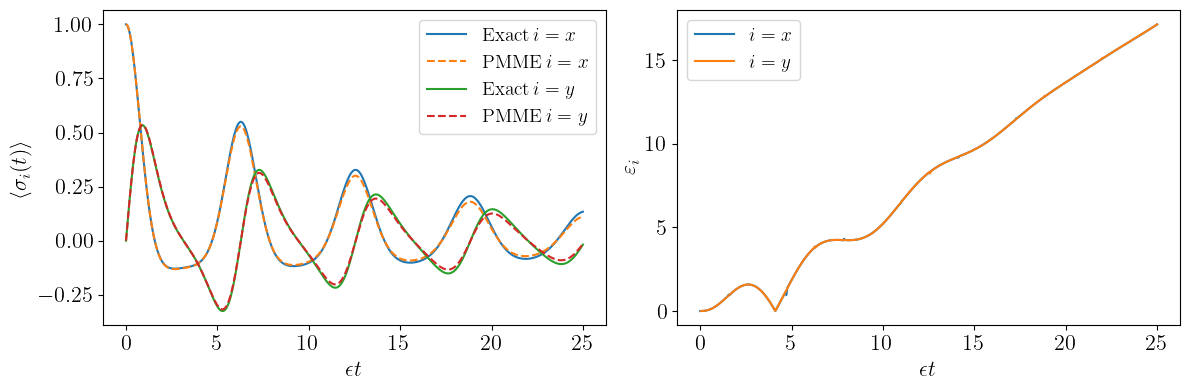

In [135]:
from pseudomodes.pure_dephasing import dephase_exp

# Initial Bloch vector
init_tls_state = init_state.ptrace(0)

bloch_vector = np.array([qt.expect(qt.sigmax(), init_tls_state), qt.expect(qt.sigmay(), init_tls_state), qt.expect(qt.sigmaz(), init_tls_state)])

# Compute time-evoled Bloch vector (decoherence function)
evolved_bloch_vector = dephase_exp(tlist_pm, bloch_vector, eps=eps, T=T, sd_type='Underdamped', coup=lmb, width=Gm, w_res=om0)

fig2, ax2 = plt.subplots(1,2, figsize=(12,4))

ax2[0].plot(tlist_pm, evolved_bloch_vector[0], label=r'$\mathrm{Exact} \, i=x$')
ax2[0].plot(tlist_pm, result.expect[0], linestyle='--', label=r'$\mathrm{PMME} \, i=x$')
ax2[0].plot(tlist_pm, evolved_bloch_vector[1], label=r'$\mathrm{Exact} \, i=y$')
ax2[0].plot(tlist_pm, result.expect[1], linestyle='--', label=r'$\mathrm{PMME} \, i=y$')

ax2[0].set_xlabel(r'$\epsilon t$')
ax2[0].set_ylabel(r'$\langle \sigma_i(t)\rangle$')
ax2[0].legend()

# Error
error_sigx = 100 * np.abs(evolved_bloch_vector[0] - result.expect[0]) / (np.abs(evolved_bloch_vector[0]))
error_sigy = 100 * np.abs(evolved_bloch_vector[1] - result.expect[1]) / (np.abs(evolved_bloch_vector[1]))

ax2[1].plot(tlist_pm, error_sigx, label=r'$i=x$')
ax2[1].plot(tlist_pm, error_sigy, label=r'$i=y$')

ax2[1].set_xlabel(r'$\epsilon t$')
ax2[1].set_ylabel(r'$\varepsilon_i$')
ax2[1].legend()

fig2.tight_layout()

plt.show()

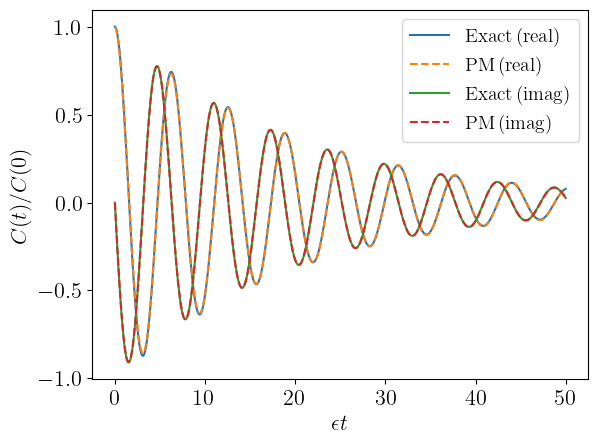

In [136]:
from pseudomodes.pure_dephasing import bcf_ud, bcf_pm

# Additional checks
fig3, ax3 = plt.subplots()

# PM correlation function
ax3.plot(tlist, np.real(bcf_ud(tlist, T=T, coup=lmb, width=Gm, w_res=om0, Nk=100)) / c0, label=r'$\mathrm{Exact \, (real)}$')
ax3.plot(tlist, np.real(bcf_pm(tlist, g, xi, gm)) / c0, linestyle='--', label=r'$\mathrm{PM \, (real)}$')
ax3.plot(tlist, np.imag(bcf_ud(tlist, T=T, coup=lmb, width=Gm, w_res=om0, Nk=100)) / c0, label=r'$\mathrm{Exact \, (imag)}$')
ax3.plot(tlist, np.imag(bcf_pm(tlist, g, xi, gm)) / c0, linestyle='--', label=r'$\mathrm{PM \, (imag)}$')

ax3.set_xlabel(r'$\epsilon t$')
ax3.set_ylabel(r'$C(t) / C(0)$')
ax3.legend()

plt.show()

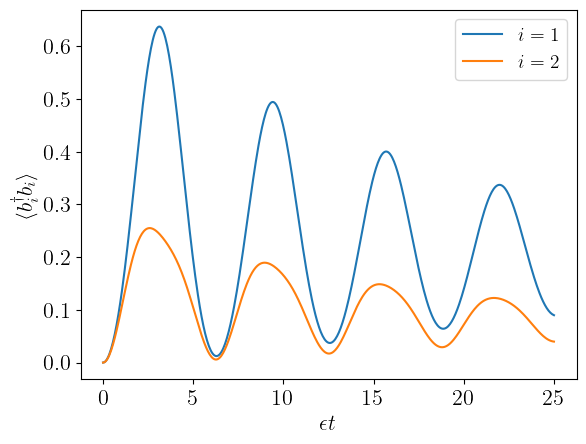

In [137]:
# Pseudomode populations - are guaranteed positive if PMME is in GKSL form
fig4, ax4 = plt.subplots()

for b in range(len(b_ops)):
    ax4.plot(tlist_pm, result.expect[b+2], label=r'$i={}$'.format(b+1))

ax4.set_xlabel(r'$\epsilon t$')
ax4.set_ylabel(r'$\langle b^{\dagger}_ib_i\rangle $')
ax4.legend()

plt.show()

In [ ]:
import json 

params = {'temperature': T, 'width': Gm, 'coupling': lmb, 'Resonance frequency': om0, 'System frequency': eps, 'Max. time': tlist_pm[-1], 'No. pseudomodes': N_exp}

beta = int(1./T)

## Save simulation data
np.save('data/ud_sigx_pure_dephasing_pm_beta_' + str(1./T) + '_lmb_' + str(lmb) + '.npy', result.expect[0])
np.save('data/ud_sigy_pure_dephasing_pm_beta_' + str(1./T) + '_lmb_' + str(lmb) + '.npy', result.expect[1])
np.save('data/ud_sigx_pure_dephasing_exact_beta_' + str(1./T) + '_lmb_' + str(lmb) +  '.npy', evolved_bloch_vector[0])
np.save('data/ud_sigy_pure_dephasing_exact_beta_' + str(1./T) + '_lmb_' + str(lmb) +  '.npy', evolved_bloch_vector[1])

# Save error data
np.save('data/ud_sigx_pure_dephasing_error_beta_' + str(1./T) + '_lmb_' + str(lmb) +  '.npy', error_sigx)
np.save('data/ud_sigy_pure_dephasing_error_beta_' + str(1./T) + '_lmb_' + str(lmb) + '.npy', error_sigy)

# Save metadata
metadata = {
    'parameters': params
}

with open ('data/metadata_beta_' + str(1./T) + '_lmb_' + str(lmb) + '.json', 'w') as f:
    json.dump(metadata, f, indent=4)
